In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings( "ignore")

In [2]:
## import dataset
os.chdir('//Users//sneha//Downloads//Python Foundation End to End Case Study E-Commerce Analytics Project')

In [3]:
cust_df=pd.read_csv('CUSTOMERS.csv')
GeoLocation_df=pd.read_csv('GEO_LOCATION.csv')
OrderItems_df=pd.read_csv('ORDER_ITEMS.csv')
orderPayment_df=pd.read_csv('ORDER_PAYMENTS.csv')
OrderReview_df=pd.read_csv('ORDER_REVIEW_RATINGS.csv')
Orders_df=pd.read_csv('ORDERS.csv')
prod_df=pd.read_csv('PRODUCTS.csv')
Sellers_df=pd.read_csv('SELLERS.csv')

In [4]:
cust_df.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,Adilabad,Andhra Pradesh


In [5]:
GeoLocation_df.head(1)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,Akkarampalle,Andhra Pradesh


In [6]:
OrderItems_df.head(1)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,9/19/2017 9:45,58.9,13.29


In [7]:
orderPayment_df.head(1)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33


In [8]:
OrderReview_df.head(1)

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,1/18/2018 0:00,1/18/2018 21:46


In [9]:
Orders_df.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00


In [10]:
prod_df.head(1)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,Perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0


In [11]:
Sellers_df.head(1)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,Alwal,Andhra Pradesh


In [12]:
dfs={'Customer':cust_df,'geo_location':GeoLocation_df,'Order_items':OrderItems_df,'order_payments':orderPayment_df,'Order_review':OrderReview_df,'Orders':Orders_df,'product':prod_df,'Seller':Sellers_df}

## Checking null values

In [13]:
for name , df in dfs.items():
    print(name)
    print('/n')
    print(df.isnull().sum()/len(df)*100)
    print('/n')

Customer
/n
customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state              0.0
dtype: float64
/n
geo_location
/n
geolocation_zip_code_prefix    0.0
geolocation_lat                0.0
geolocation_lng                0.0
geolocation_city               0.0
geolocation_state              0.0
dtype: float64
/n
Order_items
/n
order_id               0.0
order_item_id          0.0
product_id             0.0
seller_id              0.0
shipping_limit_date    0.0
price                  0.0
freight_value          0.0
dtype: float64
/n
order_payments
/n
order_id                0.0
payment_sequential      0.0
payment_type            0.0
payment_installments    0.0
payment_value           0.0
dtype: float64
/n
Order_review
/n
review_id                  0.0
order_id                   0.0
review_score               0.0
review_creation_date       0.0
review_answer_timestamp    0.0
dtype: float64
/n
Orders
/n
orde

### As null values in the columns are less than 5% we drop them

In [14]:
for name , df in dfs.items():
    df.dropna(inplace=True)

In [15]:
for name , df in dfs.items():
    print( name)
    print('/n')
    print(df.isnull().sum()/len(df)*100)
    print('/n')

Customer
/n
customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state              0.0
dtype: float64
/n
geo_location
/n
geolocation_zip_code_prefix    0.0
geolocation_lat                0.0
geolocation_lng                0.0
geolocation_city               0.0
geolocation_state              0.0
dtype: float64
/n
Order_items
/n
order_id               0.0
order_item_id          0.0
product_id             0.0
seller_id              0.0
shipping_limit_date    0.0
price                  0.0
freight_value          0.0
dtype: float64
/n
order_payments
/n
order_id                0.0
payment_sequential      0.0
payment_type            0.0
payment_installments    0.0
payment_value           0.0
dtype: float64
/n
Order_review
/n
review_id                  0.0
order_id                   0.0
review_score               0.0
review_creation_date       0.0
review_answer_timestamp    0.0
dtype: float64
/n
Orders
/n
orde

### All null values are treated

## Check duplicates

In [16]:
for name , df in dfs.items():
    print( name)
    print(df.duplicated().sum())
  

Customer
0
geo_location
0
Order_items
0
order_payments
0
Order_review
0
Orders
0
product
0
Seller
0


### There is no duplicates

In [17]:
for name , df in dfs.items():
    df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
 3   geolocation_city             19015 non-null  object 
 4   geo

## Check Discripancies

In [18]:
for name , df in dfs.items():
    print(name)
    print('/n')
    for i in df.select_dtypes(include='object'):
       print(df[i].value_counts())
    print('/n')

Customer
/n
customer_id
06b8999e2fba1a1fbc88172c00ba8bc7    1
c023f30c1147aeb0358474f3b1dbc707    1
b5cbf43f42281920a175fc99650c91d6    1
19f4e983f8f05b7de16670f8a0cf0ac7    1
229ac14c6ee6d6a606264ebcc861beb7    1
                                   ..
31665bd5bc542687ab54c9fd9ed9917b    1
37fb9cce079a4887c96b59bae2011d05    1
1d815f3ad9b2017b6da2c4f1cbb1180b    1
6b05c8f3a25a71005d5eb9b51766c333    1
274fa6071e5e17fe303b9748641082c8    1
Name: count, Length: 99441, dtype: int64
customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
081f07439678af2da7755a0aa572154d     1
9c57789a6a587f4efcfb01e36c106014     1
9e4c21635f640562de1a6976374fba03     1
06c0ea6ee892364d1608ee47aa9f56a0     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64
customer_city
Akkarampalle  

### There is no discripancies in the data

In [19]:
## calculate Total Revenue, Total quantity, Totalproducts, Total categories, Total sellers, Total locations, Total channels, Total payment methods etc

In [20]:
orderPayment_df.head(2)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39


In [21]:
OrderItems_df.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,9/19/2017 9:45,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,5/3/2017 11:05,239.9,19.93


In [22]:
Orders_df.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00


In [23]:
## calculate Total Revenue, Total quantity, Totalproducts, Total categories, Total sellers, Total locations, Total channels, Total payment methods etc

In [24]:
#total Revenue
Total_revenue=orderPayment_df.payment_value.sum()

In [25]:
Total_revenue

np.float64(16008872.12)

In [26]:
## Total_quantity
Total_quantity=OrderItems_df.order_item_id.count()

In [27]:
Total_quantity

np.int64(112650)

In [28]:
## Total_products
prod_df.head(2)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,Perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,Art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


In [29]:
Total_prod=prod_df.product_id.count()

In [30]:
Total_prod

np.int64(32327)

### The business offers 32,327 unique products, with a total order quantity of 112,650 units sold, generating an overall revenue of ₹16,008,872
### Despite a large product catalog, the high order volume indicates strong demand, contributing significantly to revenue generation

In [31]:
## Total_categories
Total_categories=prod_df.product_category_name.nunique()

In [32]:
Total_categories

71

In [33]:
cat_wise_products=(prod_df[['product_id','product_category_name']].groupby(by='product_category_name').count()).sort_values(by='product_id',ascending=False)

In [34]:
cat_wise_products

,product_id
product_category_name,
Bed_Bath_Table,3029
Sports_Leisure,2867
Furniture_Decor,2657
Health_Beauty,2444
Housewares,2335
...,...
Tablets_Printing_Image,9
Home_Comfort_2,5
Fashion_Childrens_Clothes,5


In [180]:
## Total_sellers
Total_sellers=Sellers_df.seller_id.count()
Total_sellers

np.int64(3038)

In [181]:
## Total_Locations
Total_Locations=GeoLocation_df.geolocation_zip_code_prefix.count()
Total_Locations

np.int64(19015)

In [37]:
## Total channels
orderPayment_df.payment_type.nunique()

5

In [38]:
Orders_df['order_date']=pd.to_datetime(Orders_df.order_approved_at)

In [39]:
oc_df=pd.merge(left=Orders_df,right=cust_df,left_on='customer_id',right_on='customer_id')

In [40]:
oc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96461 entries, 0 to 96460
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  object        
 4   order_approved_at              96461 non-null  object        
 5   order_delivered_carrier_date   96461 non-null  object        
 6   order_delivered_customer_date  96461 non-null  object        
 7   order_estimated_delivery_date  96461 non-null  object        
 8   order_date                     96461 non-null  datetime64[ns]
 9   customer_unique_id             96461 non-null  object        
 10  customer_zip_code_prefix       96461 non-null  int64         
 11  customer_city  

In [41]:
first_order=oc_df[['customer_unique_id','order_date']].groupby(by='customer_unique_id').min()

In [42]:
oc_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,2017-10-02 11:07:00,7c396fd4830fd04220f754e42b4e5bff,3149,Akkarampalle,Andhra Pradesh
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00,2018-07-26 03:24:00,af07308b275d755c9edb36a90c618231,47813,Pandariya,Chhattisgarh
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00,2018-08-08 08:55:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,Dhamdha,Chhattisgarh
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00,2017-11-18 19:45:00,7c142cf63193a1473d2e66489a9ae977,59296,Kartarpur,Punjab
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00,2018-02-13 22:20:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,Bheemavaram,Andhra Pradesh


In [43]:
first_order['month_num']=first_order.order_date.dt.month

In [44]:
first_order['month']=first_order.order_date.dt.month_name()

In [45]:
first_order.reset_index(inplace=True)

In [46]:
first_order

,customer_unique_id,order_date,month_num,month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 11:11:00,5,May
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 18:25:00,5,May
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,3,March
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:49:00,10,October
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 20:06:00,11,November
...,...,...,...,...
93337,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:15:00,6,June
93338,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:16:00,12,December
93339,ffff371b4d645b6ecea244b27531430a,2017-02-07 16:02:00,2,February
93340,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:58:00,5,May


In [47]:
new_cust=first_order.groupby(['month_num','month'])['customer_unique_id'].count().reset_index(name='customer_count')

## New Customer acquired per month

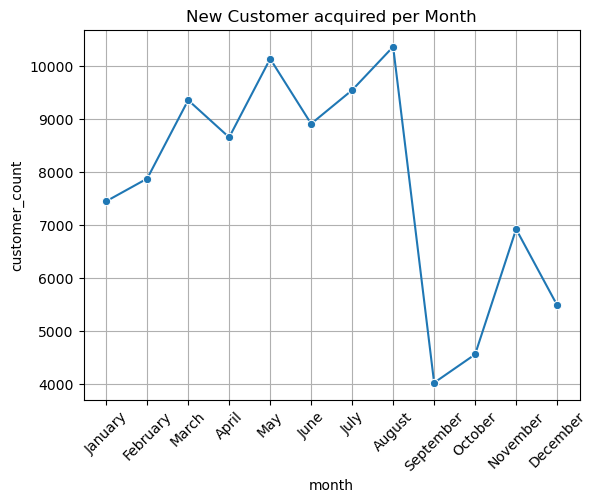

In [48]:
sns.lineplot(data=new_cust,x='month',y='customer_count',marker='o')

plt.title('New Customer acquired per Month')
plt.xlabel('month')
plt.ylabel('customer_count')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [49]:
## Understand the retention of customers on month on month basis
oc_df['month']=oc_df.order_date.dt.month_name()

In [50]:
df=oc_df[['customer_unique_id','month']].drop_duplicates()

In [51]:
df['month']=oc_df.order_date.dt.to_period('M')

In [52]:
df=df.sort_values(by='month')

In [53]:
df['prev_month']=df.groupby('customer_unique_id')['month'].shift(1)

In [54]:
df['retained']=df['month']==df['prev_month']+1

In [55]:
retention_count=df.groupby('month')['retained'].sum().sort_index()

In [56]:
retention_count=df.groupby('month')['retained'].sum().sort_index()

In [57]:
retention_count=retention_count.reset_index()

In [58]:
retention_count['month']=retention_count['month'].dt.to_timestamp()

In [59]:
retention_count['month'] = retention_count['month'].dt.strftime('%b-%Y')

## Retention of customers on month on month basis

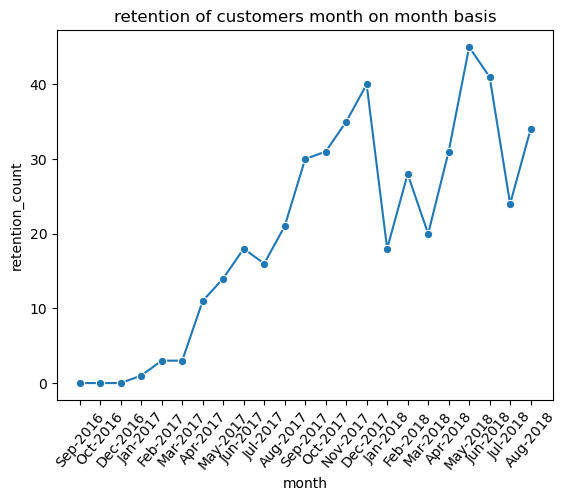

In [60]:
sns.lineplot(data=retention_count,x='month',y='retained',marker='o')
plt.title('retention of customers month on month basis')
plt.xlabel('month')
plt.ylabel('retention_count')
plt.xticks(rotation=50)
plt.show()

In [61]:
## How the revenues from existing/new customers on month on month basis

In [62]:
f_df=first_order.groupby(['month_num','month','customer_unique_id'])['customer_unique_id'].count().sort_index()


In [63]:
new_cust_df=f_df.reset_index(name='count')

In [64]:
new_cust_df.drop(['month_num','count'],inplace=True,axis=1)

In [65]:
retained_cust_df=df[df['retained']==True]['customer_unique_id']

In [66]:
co_df=oc_df[['customer_unique_id','order_id','order_date']]

In [67]:
final_df_new=pd.merge(left=new_cust_df,right=co_df,left_on='customer_unique_id',right_on='customer_unique_id',how='left')

In [68]:
final_df_ret=pd.merge(left=retained_cust_df,right=co_df,left_on='customer_unique_id',right_on='customer_unique_id',how='left')

In [69]:
final_df_new['month']=final_df_new.order_date.dt.to_period('M')

In [70]:
final_df_ret['month']=final_df_ret.order_date.dt.to_period('M')

In [71]:
final_df_new=pd.merge(left=final_df_new,right=orderPayment_df,left_on='order_id',right_on='order_id',how='left')

In [72]:
final_df_ret=pd.merge(left=final_df_ret,right=orderPayment_df,left_on='order_id',right_on='order_id',how='left')

In [182]:
month_rev_new=final_df_new.groupby('month')['payment_value'].sum().reset_index(name='new_cust_rev')

In [183]:
month_rev_ret=final_df_ret.groupby('month')['payment_value'].sum().reset_index(name='old_cust_rev')

In [184]:
final_df = pd.concat([month_rev_new, month_rev_ret],axis=1)

In [186]:
final_df

,month,new_cust_rev,month,old_cust_rev
0,2016-09,0.00,2016-12,19.62
1,2016-10,47271.20,2017-01,357.78
2,2016-12,19.62,2017-02,717.36
3,2017-01,121947.60,2017-03,2217.97
4,2017-02,270809.17,2017-04,3854.16
5,2017-03,410773.10,2017-05,5647.62
6,2017-04,387909.63,2017-06,5145.16
7,2017-05,568103.33,2017-07,6582.94
8,2017-06,494527.07,2017-08,9011.02
9,2017-07,560380.56,2017-09,11028.83


## Category wise sales analysis

In [77]:
op_df=pd.merge(left=OrderItems_df,right=prod_df,left_on='product_id',right_on='product_id',how='left')

In [78]:
final_df1=pd.merge(left=orderPayment_df,right=op_df,left_on='order_id',right_on='order_id',how='left')

In [79]:
final_df1.groupby('product_category_name')['payment_value'].sum().reset_index().sort_values(by='payment_value',ascending=False)

,product_category_name,payment_value
7,Bed_Bath_Table,1712553.67
43,Health_Beauty,1657373.12
15,Computers_Accessories,1585330.45
39,Furniture_Decor,1430176.39
70,Watches_Gifts,1429216.68
...,...,...
35,Flowers,2213.01
46,Home_Comfort_2,1710.54
11,Cds_Dvds_Musicals,1199.43
29,Fashion_Childrens_Clothes,785.67


### observations:
- Bed_Bath_Table category generated the highest revenue (~1.71M), making it the top-performing category.
- Health_Beauty and Computers_Accessories also contribute significantly to overall sales.
- These categories dominate customer demand and revenue generation.

## Location wise sales analysis

In [80]:
final_df2=pd.merge(left=Orders_df,right=cust_df,left_on='customer_id',right_on='customer_id',how='left')

In [81]:
final_df2=pd.merge(left=orderPayment_df,right=final_df2,left_on='order_id',right_on='order_id',how='left')

In [82]:
final_df2.groupby(['customer_state','customer_city'])['payment_value'].sum().reset_index().sort_values(by='payment_value',ascending=False)

,customer_state,customer_city,payment_value
2,Andhra Pradesh,Akkarampalle,2108073.49
10,Andhra Pradesh,Badepalle,1112156.04
8,Andhra Pradesh,Anantapur,406050.87
40,Andhra Pradesh,Eddumailaram,345221.87
7,Andhra Pradesh,Anakapalle,238582.26
...,...,...,...
2774,Tamil Nadu,Nagojanahalli,24.23
4016,West Bengal,Panihati,24.09
2452,Tamil Nadu,Arimalam,22.58
2166,Punjab,Moonak,20.70


### observations
- Akkarampalle (Andhra Pradesh) is the top-performing city contributing the highest revenue (~2.1M)
- Other cities like Badepalle and Anantapur also generate significant sales
- Some cities like Vellore and Moonak contribute very minimal revenue, indicating low customer activity

## Andhra Pradesh dominates in terms of revenue, as multiple top-performing cities belong to this state

In [83]:
final_df3=pd.merge(left=orderPayment_df,right=Orders_df,left_on='order_id',right_on='order_id',how='left')

In [84]:
final_df3['month_num']=final_df3.order_date.dt.month

In [85]:
final_df3['month']=final_df3.order_date.dt.month_name()

In [86]:
final_df3.groupby(['month_num','month'])['payment_value'].sum().reset_index().sort_values(by='payment_value',ascending=False)

,month_num,month,payment_value
4,5.0,May,1723505.05
7,8.0,August,1660713.55
6,7.0,July,1566377.74
2,3.0,March,1543280.56
5,6.0,June,1509644.76
3,4.0,April,1497514.81
1,2.0,February,1229560.29
0,1.0,January,1192051.94
10,11.0,November,1135086.55
11,12.0,December,868081.18


In [87]:
final_df3['week']=final_df3.order_date.dt.isocalendar().week

In [88]:
final_df3['day_num']=final_df3.order_date.dt.day_of_week

In [89]:
final_df3['day']=final_df3.order_date.dt.day_name()

### Month wise analysis

In [90]:
month_wise_sales=final_df3.groupby(['month_num','month'])['payment_value'].sum().reset_index(name='sales')

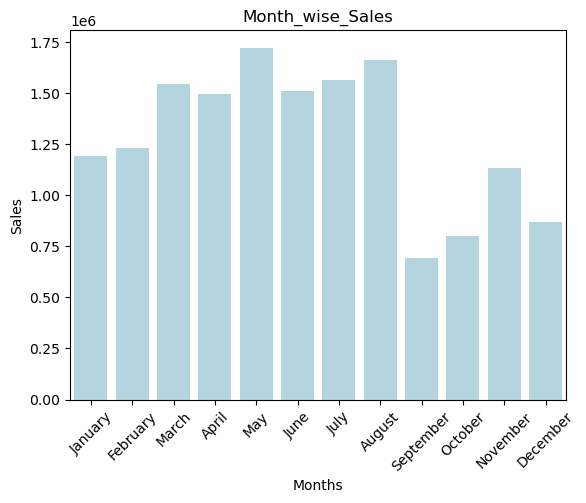

In [91]:
sns.barplot(data=month_wise_sales,x='month',y='sales',color='lightblue')
plt.title('Month_wise_Sales')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

### MONTH-WISE INSIGHTS
- May highest sales (~1.72M)
- August & July are also strong months 
- September & October lowest performing months
 -Sales peaks mid-year (May–Aug) 

### Week wise analysis

In [92]:
final_df3.groupby('week')['payment_value'].sum().reset_index().sort_values(by='payment_value',ascending=False)

,week,payment_value
18,19,474010.51
30,31,467032.64
31,32,464314.74
16,17,443847.61
19,20,432840.97
46,47,431337.41
29,30,413280.45
32,33,405321.00
28,29,384843.33
8,9,376314.98


### WEEK-WISE INSIGHTS
- Sales are not evenly distributed across weeks
- some weeks (e.g., Week 31–32, 16–17, 19–20) shows higher sales 
- noticebale drop in last weeks (Week 51–52) 
 -Indicates periodic spikes, not consistent trend

In [93]:
day_wise_sales=final_df3.groupby('day')['payment_value'].sum().reset_index().sort_values(by='payment_value',ascending=False)

In [94]:
day_wise_sales=final_df3.groupby('day')['payment_value'].sum().reset_index(name='sales').sort_values(by='sales',ascending=False)

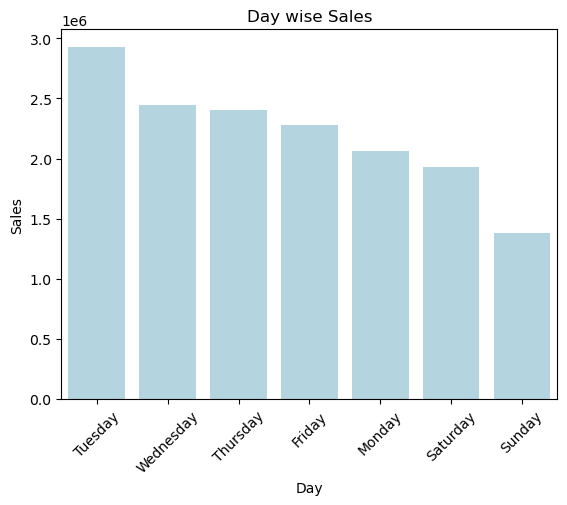

In [95]:
sns.barplot(data=day_wise_sales,x='day',y='sales',color='lightblue')
plt.title('Day wise Sales')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

### DAY-WISE INSIGHTS
- Tuesday highest sales (~2.92M) → peak shopping day
- Wednesday & Thursday also shows strong 
- Sunday lowest sales (~1.38M) → weakest day
- Overall, weekdays > weekends


In [96]:
## Popular Products by month, seller, state, category

In [97]:
op_df=pd.merge(left=Orders_df,right=OrderItems_df,left_on='order_id',right_on='order_id',how='left')

In [98]:
op_df['month']=op_df.order_date.dt.month_name()
op_df['month_num']=op_df.order_date.dt.month

In [99]:
oi_df=op_df[['month_num','order_id','product_id','month']]

In [100]:
monthdf=oi_df.groupby(['month_num','month','product_id'])['order_id'].count().reset_index(name='order_count')

### Popular products by month

In [101]:
os_df=pd.merge(left=op_df,right=Sellers_df,left_on='seller_id',right_on='seller_id',how='left')

In [102]:
monthdf.loc[monthdf.groupby(['month_num','month'])['order_count'].idxmax()]

,month_num,month,product_id,order_count
2990,1,January,aca2eb7d00ea1a7b8ebd4e68314663af,122
8734,2,February,e53e557d5a159f5aa2c5e995dfdf244b,72
13082,3,March,aca2eb7d00ea1a7b8ebd4e68314663af,67
18691,4,April,aca2eb7d00ea1a7b8ebd4e68314663af,83
22641,5,May,53b36df67ebb7c41585e8d54d6772e08,118
28365,6,June,42a2c92a0979a949ca4ea89ec5c7b934,71
36339,7,July,99a4788cb24856965c36a24e339b6058,70
45194,8,August,e7cc48a9daff5436f63d3aad9426f28b,67
46571,9,September,422879e10f46682990de24d770e7f83d,37
49421,10,October,422879e10f46682990de24d770e7f83d,39


In [103]:
os_df=pd.merge(left=op_df,right=Sellers_df,left_on='seller_id',right_on='seller_id',how='left')

In [104]:
os_df=os_df[['seller_id','product_id','order_id']].groupby(['seller_id','product_id'])['order_id'].count().reset_index(name='order_count')

### Popular product by seller

In [105]:
os_df.loc[os_df.groupby('seller_id')['order_count'].idxmax()]

,seller_id,product_id,order_count
0,0015a82c2db000af6aaaf3ae2ecb0532,a2ff5a97bf95719e38ea2e3b4105bce8,3
1,001cca7ae9ae17fb1caed9dfb1094831,08574b074924071f4e201e151b152b4e,110
13,002100f778ceb8431b7a1020ff7ab48f,158102fe543dbaeb84d87811bfe06d0d,16
36,003554e2dce176b5555353e4f3555ac8,67f36b3689147d882d2b298fd0715d80,1
68,004c9cd9d87a3c30c522c48c4fc07416,54af11c815f92135fb554bd9c97dd418,13
...,...,...,...
33591,ffc470761de7d0232558ba5e786e57b7,460a66fcc404a3d7306d5f50fcb2d18a,6
33612,ffdd9f82b9a447f6f8d4b91554cc7dd3,ada800a927673ac73cdfbbd2c832331b,5
33617,ffeee66ac5d5a62fe688b9d26f83f534,1347d4320dcd0acd750e37bb3d94a918,10
33644,fffd5413c0700ac820c7069d66d98c89,ebb12274522d82caa7dca657873b2ad7,5


In [106]:
oc_df=pd.merge(left=op_df,right=cust_df,left_on='customer_id',right_on='customer_id',how='left')

In [107]:
oc_df=oc_df[['customer_state','product_id','order_id']].groupby(['customer_state','product_id'])['order_id'].count().reset_index(name='order_count')

### Popular products by state

In [108]:
oc_df.loc[oc_df.groupby('customer_state')['order_count'].idxmax()]

,customer_state,product_id,order_count
15953,Andhra Pradesh,aca2eb7d00ea1a7b8ebd4e68314663af,339
23741,Arunachal Pradesh,03e1c946c0ddfc58724ff262aef08dff,12
25685,Chhattisgarh,368c6c730842d78016ad823897a372db,40
30118,Delhi,53759a2ecddad2bb87a079a1f1519f73,22
31864,Goa,2a5806f10d0f00e5ad032dd2e3c8806e,1
33530,Gujarat,53759a2ecddad2bb87a079a1f1519f73,45
37326,Haryana,2b4609f8948be18874494203496bc318,13
39012,Himachal Pradesh,422879e10f46682990de24d770e7f83d,6
40226,Jammu & Kashmir,89b190a046022486c635022524a974a8,15
41594,Karnataka,422879e10f46682990de24d770e7f83d,24


In [109]:
opp_df=pd.merge(left=OrderItems_df,right=prod_df,left_on='product_id',right_on='product_id',how='left')

In [110]:
opp1_df=opp_df.groupby(['product_category_name','product_id'])['order_id'].count().reset_index(name='order_count')

### Popular product by category

In [111]:
opp1_df.loc[opp1_df.groupby('product_category_name')['order_count'].idxmax()]

,product_category_name,product_id,order_count
7,Agro_Industry_And_Commerce,11250b0d4b709fee92441c5f34122aed,22
144,Air_Conditioning,98e91d0f32954dcd8505875bb2b42cdb,17
218,Art,4fe644d766c7566dbc46fb851363cb3b,107
267,Arts_And_Craftmanship,b9976e9c22fb1540bd71d1bcd2989475,5
316,Audio,db5efde3ad0cc579b130d71c4b2db522,48
...,...,...,...
28425,Stationery,fb55982be901439613a95940feefd9ee,84
28448,Tablets_Printing_Image,6bbe55cf8f85c87b6eebb775a53402f4,33
29469,Telephony,e7cc48a9daff5436f63d3aad9426f28b,93
30359,Toys,880be32f4db1d9f6e2bec38fb6ac23ab,99


In [112]:
## Popular categories by state, month

In [113]:
opp1_df

,product_category_name,product_id,order_count
0,Agro_Industry_And_Commerce,018ca97302e4293050cc41413194bb19,1
1,Agro_Industry_And_Commerce,026f43af35e7951067097527d5c31bcc,2
2,Agro_Industry_And_Commerce,07f01b6fcacc1b187a71e5074199db2d,1
3,Agro_Industry_And_Commerce,0a0adf0de1769b2970f3096d0b5abfb7,1
4,Agro_Industry_And_Commerce,0a27862bbf658a5b8cf655761bc5c72d,1
...,...,...,...
32322,Watches_Gifts,ff5d87897ed26d564711df324b98ebee,6
32323,Watches_Gifts,ff7b4560eaf93a8848cd5fde641f39c6,1
32324,Watches_Gifts,ff80f0538290775336ee74b4997a855c,1
32325,Watches_Gifts,ffd2365fb8224dc66883df9351d65deb,3


In [114]:
oc_df=pd.merge(left=opp_df,right=Orders_df,left_on='order_id',right_on='order_id',how='left')

In [115]:
oc_df1=pd.merge(left=oc_df,right=cust_df,left_on='customer_id',right_on='customer_id',how='left')

In [116]:
oc_df1=oc_df1[['customer_state','product_category_name','order_id']].groupby(['customer_state','product_category_name'])['order_id'].count().reset_index(name='order_count')

### Popular categories by state

In [117]:
oc_df1.loc[oc_df1.groupby('customer_state')['order_count'].idxmax()]

,customer_state,product_category_name,order_count
7,Andhra Pradesh,Bed_Bath_Table,6977
77,Arunachal Pradesh,Bed_Bath_Table,114
132,Chhattisgarh,Bed_Bath_Table,677
228,Delhi,Health_Beauty,324
254,Goa,Auto,1
271,Gujarat,Bed_Bath_Table,775
338,Haryana,Bed_Bath_Table,278
394,Himachal Pradesh,Bed_Bath_Table,82
446,Jammu & Kashmir,Bed_Bath_Table,159
503,Karnataka,Bed_Bath_Table,376


In [118]:
oc_df['month_num']=oc_df.order_date.dt.month

In [119]:
oc_df['month']=oc_df.order_date.dt.month_name()

In [120]:
oc_df2=oc_df[['month_num','month','product_category_name','order_id']].groupby(['month_num','month','product_category_name'])['order_id'].count().reset_index(name='order_count')

### Popular categories by month

In [121]:
oc_df2.loc[oc_df2.groupby(['month_num','month'])['order_count'].idxmax()]

,month_num,month,product_category_name,order_count
6,1.0,January,Bed_Bath_Table,857
81,2.0,February,Computers_Accessories,1081
138,3.0,March,Bed_Bath_Table,1057
206,4.0,April,Bed_Bath_Table,993
275,5.0,May,Bed_Bath_Table,1125
342,6.0,June,Bed_Bath_Table,1127
409,7.0,July,Bed_Bath_Table,1182
512,8.0,August,Health_Beauty,1199
545,9.0,September,Bed_Bath_Table,527
609,10.0,October,Bed_Bath_Table,553


## top 10 most expensive products sorted by price

In [122]:
OrderItems_df[['product_id','price']].sort_values(by='price',ascending=False).head(10)

,product_id,price
3556,489ae2aa008f021502940f251d4cce7f,6735.00
112233,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00
107841,1bdf5e6731585cf01aa8169c7028d6ad,6499.00
74336,a6492cc69376c469ab6f61d8f44de961,4799.00
11249,c3ed642d592594bb648ff4a04cee2747,4690.00
62086,259037a6a41845e455183f89c5035f18,4590.00
29193,a1beef8f3992dbd4cd8726796aa69c53,4399.87
45843,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99
78310,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00
59137,6902c1962dd19d540807d0ab8fade5c6,3999.90


In [123]:
## Deviding customers group based on revenue geenrated
opay_df=pd.merge(left=Orders_df,right=orderPayment_df,left_on='order_id',right_on='order_id',how='left')

In [124]:
opayc_df=pd.merge(left=opay_df,right=cust_df,left_on='customer_id',right_on='customer_id',how='left')

In [125]:
opayc_df.payment_value.max()

13664.08

In [126]:
opayc_df.payment_value.min()

0.0

In [127]:
bins=[0,200,500,1000,float('inf')]

In [128]:
labels=['D','C','B','A']

In [129]:
opayc1_df=opayc_df.groupby(['customer_unique_id'])['payment_value'].sum().reset_index(name='revenue')

In [130]:
opayc1_df['Group']=pd.cut(opayc1_df['revenue'],bins=bins,labels=labels)

In [131]:
A_group=opayc1_df[opayc1_df['Group']=='A']

In [132]:
B_group=opayc1_df[opayc1_df['Group']=='B']

In [133]:
C_group=opayc1_df[opayc1_df['Group']=='C']

In [134]:
D_group=opayc1_df[opayc1_df['Group']=='D']

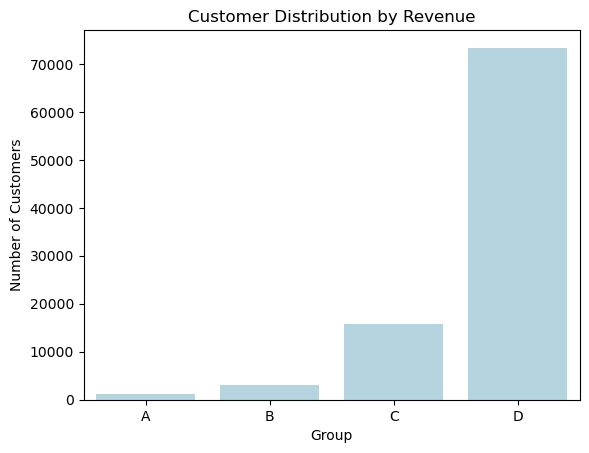

In [135]:
sns.countplot(data=opayc1_df,x='Group',order=['A','B','C','D'],color='lightblue')
plt.title('Customer Distribution by Revenue')
plt.xlabel('Group')
plt.ylabel('Number of Customers')

plt.show()

### Majority of customers fall into D group, while C group  have fewer customer and A and B group have comparatively very low customers

In [136]:
## Total revenue generated by group A customer
A_group['revenue'].sum()

np.float64(1820362.03)

In [137]:
## Total revenue generated by group B customer
B_group['revenue'].sum()

np.float64(2117276.26)

In [138]:
## Total revenue generated by group C customer
C_group['revenue'].sum()

np.float64(4584537.93)

In [139]:
## Total revenue generated by group D customer
D_group['revenue'].sum()

np.float64(6897506.630000001)

## Dividing Salers into groups based on revenue generated

In [140]:
os_df=pd.merge(left=OrderItems_df,right=Sellers_df,left_on='seller_id',right_on='seller_id',how='left')

In [141]:
os1_df=pd.merge(left=orderPayment_df,right=os_df,left_on='order_id',right_on='order_id',how='left')

In [142]:
os2_df=os1_df.groupby(['seller_id'])['payment_value'].sum().reset_index(name='revenue')

In [143]:
os2_df['Group']=pd.cut(os2_df['revenue'],bins=bins,labels=labels)

In [144]:
A_goup=os2_df[os2_df['Group']=='A']

In [145]:
B_group=os2_df[os2_df['Group']=='B']

In [146]:
C_group=os2_df[os2_df['Group']=='C']

In [147]:
D_group=os2_df[os2_df['Group']=='D']

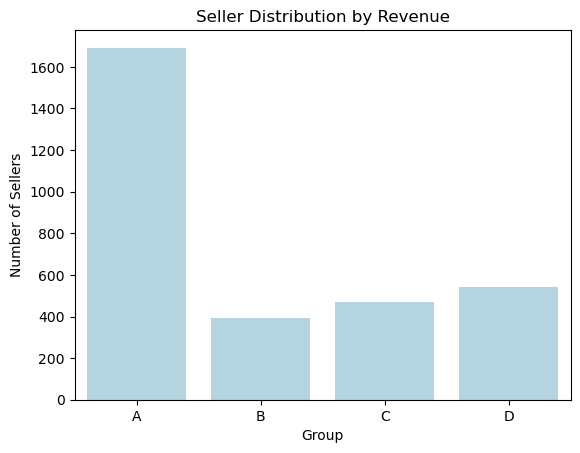

In [148]:
sns.countplot(data=os2_df,x='Group',order=['A','B','C','D'],color='lightblue')
plt.title('Seller Distribution by Revenue')
plt.xlabel('Group')
plt.ylabel('Number of Sellers')

plt.show()

### Majority of sellers fall into A  group, while B, C and D groups have comparatively fewer sellers

In [149]:
## which of the top 10 combinations of products are selling together in
Oip_df=pd.merge(left=OrderItems_df,right=prod_df,left_on='product_id',right_on='product_id',how='left')

In [150]:
oo_df=pd.merge(left=Orders_df,right=Oip_df,left_on='order_id',right_on='order_id',how='left')

In [151]:
oo_df=oo_df[['order_id','product_id']]

In [152]:
pair_df=oo_df.merge(oo_df,on='order_id')
pair_df

,order_id,product_id_x,product_id_y
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,87285b34884572647811a353c7ac498a
1,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,595fac2a385ac33a80bd5114aec74eb8
2,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,aa4383b373c6aca5d8797843e5594415
3,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,d0b61bfb1de832b15ba9d266ca96e5b0
4,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,65266b2da20d04dbe00c5c2d3bb7859e
...,...,...,...
153853,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,d1c427060a0f73f6b889a5c7c61f2ac4
153854,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,d1c427060a0f73f6b889a5c7c61f2ac4
153855,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,d1c427060a0f73f6b889a5c7c61f2ac4
153856,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,d1c427060a0f73f6b889a5c7c61f2ac4


In [153]:
pair_df=pair_df[pair_df['product_id_x']!=pair_df['product_id_y']]

In [154]:
def make_pair(row):
    return tuple(sorted([row['product_id_x'],row['product_id_y']]))
pair_df['pair']=pair_df.apply(make_pair,axis=1)

In [155]:
pair_count = pair_df['pair'].value_counts().reset_index()

In [156]:
pair_count.columns = ['product_pair', 'count']

In [157]:
pair_count = pair_count.sort_values(by='count', ascending=False)

### Top 10 combinations of products are selling together in

In [158]:
pair_count.head(10)

,product_pair,count
0,"(05b515fdc76e888aada3c6d66c201dff, 270516a3f41...",200
1,"(36f60d45225e60c7da4558b070ce4b60, e53e557d5a1...",96
2,"(710b7c26b7a742f497bba45fab91a25f, a9d9db064d4...",72
3,"(62995b7e571f5760017991632bbfd311, ac1ad58efc1...",72
4,"(2ef36e1cae01b86d0ff0a2f50ff2bd53, 53759a2ecdd...",60
5,"(35afc973633aaeb6b877ff57b2793310, 99a4788cb24...",60
6,"(308e4e21ae228a10f6370a243ae59995, 90b58782fdd...",60
7,"(18486698933fbb64af6c0a255f7dd64c, dbb67791e40...",50
8,"(58efb9b638561ce132216a9a612513e2, 872db866d61...",50
11,"(0db4869ac8a908414823d44d742f5ba3, 47920da896b...",48


In [159]:
## Payment Behaviour
opayc_df[['customer_unique_id','payment_type']]

,customer_unique_id,payment_type
0,7c396fd4830fd04220f754e42b4e5bff,credit_card
1,7c396fd4830fd04220f754e42b4e5bff,voucher
2,7c396fd4830fd04220f754e42b4e5bff,voucher
3,af07308b275d755c9edb36a90c618231,UPI
4,3a653a41f6f9fc3d2a113cf8398680e8,credit_card
...,...,...
100735,6359f309b166b0196dbf7ad2ac62bb5a,credit_card
100736,da62f9e57a76d978d02ab5362c509660,credit_card
100737,737520a9aad80b3fbbdad19b66b37b30,credit_card
100738,5097a5312c8b157bb7be58ae360ef43c,credit_card


In [160]:
opayc_df[['customer_unique_id','payment_type']].groupby('payment_type')['customer_unique_id'].count()

payment_type
UPI            19177
credit_card    74584
debit_card      1485
voucher         5493
Name: customer_unique_id, dtype: int64

### UPI and Credit_card are most popular methods for payment

In [161]:
## Customer satisfaction towards category & product
OR_df=pd.merge(left=OrderReview_df,right=Orders_df,left_on='order_id',right_on='order_id',how='left')

In [162]:
OR_df1=pd.merge(left=OR_df,right=cust_df,left_on='customer_id',right_on='customer_id',how='left')

In [163]:
OR_df1=pd.merge(left=OR_df1,right=oi_df,left_on='order_id',right_on='order_id',how='left')

In [164]:
OR_df1=pd.merge(left=OR_df1,right=prod_df,left_on='product_id',right_on='product_id',how='left')

In [165]:
OR_df2=OR_df1[['product_category_name','review_score']]

In [166]:
OR_df2.drop_duplicates(inplace=True)

### Top 10 maximum rated categories

In [167]:
OR_df2.sort_values(by='review_score',ascending=False).head(10)

,product_category_name,review_score
6180,Fixed_Telephony,5
18744,Party_Supplies,5
538,Furniture_Bedroom,5
534,Kitchen_Dining_Laundry_Garden_Furniture,5
469,Drinks,5
457,Construction_Tools_Construction,5
443,Market_Place,5
4278,Tablets_Printing_Image,5
357,Luggage_Accessories,5
355,Consoles_Games,5


### Top 10 minimum rated categories

In [168]:
OR_df2.sort_values(by='review_score',ascending=True).head(10)

,product_category_name,review_score
199,Telephony,1
282,Books_Imported,1
280,Auto,1
8387,Party_Supplies,1
238,Housewares,1
2006,Fixed_Telephony,1
10091,Flowers,1
993,Consoles_Games,1
214,Audio,1
213,Home_Appliances,1


In [169]:
OR_df3=OR_df1[['product_id','review_score']]

In [170]:
OR_df3.drop_duplicates(inplace=True)

### Top 10 maximum rated products

In [171]:
OR_df3.sort_values(by='review_score',ascending=False).head(10)

,product_id,review_score
44392,e224399b59101fa9f7607737c7961f1b,5
29724,103cc8c441a717d9a54fca312ae8ec3c,5
74094,9376771cb92c045ec36c97fb810f1f90,5
29721,0e429613002a4b7dfa4554005e2ab8d2,5
74095,da83f50064bb1755c5a15ecd22773671,5
29717,f99e92b9472a8d08d27cfc7e98292b42,5
74096,f000b8e179dc162f26046103cd109ea3,5
74104,c82f1b01c42306423e552a3df6875291,5
74113,bc166ad2b244b9d4eec97208498b1c07,5
29705,eab2f90face23112d9bf1d4d3e641696,5


### Top 10 minimum rated products

In [172]:
OR_df3.sort_values(by='review_score',ascending=True).head(10)

,product_id,review_score
44388,de9c7592ce4a5f5ac77c2f360698d44e,1
36937,9d0bb30eed80184666c8acad23921283,1
36946,8c0c5d88d9ec2bc8e02395bda8ea52f2,1
36965,5328338cfaa16ba10561cd970c73ca11,1
36970,3cf8d7db7dbaeb28f077151adfc59340,1
36989,1d1a36ff369b6838f8220870f96254a0,1
37032,51e8feeedd83467b86a79aa2769367c5,1
37064,60575d29211e79ad70c3f9e0626d255a,1
37065,bd336707deb508edc61ee62f22706cc4,1
37079,3a98bcea866c31f53b35a41d3822f908,1


In [173]:
##Average rating by location, seller, product, category, month etc.

In [174]:
oc_df=pd.merge(left=oc_df,right=cust_df,left_on='customer_id',right_on='customer_id',how='left')

In [175]:
oc_df=pd.merge(left=oc_df,right=OrderReview_df,left_on='order_id',right_on='order_id',how='left')

### average rating by Location

In [176]:
round(oc_df[['customer_state','review_score']].groupby('customer_state')['review_score'].mean(),1).reset_index(name='avg review score')

,customer_state,avg review score
0,Andhra Pradesh,4.1
1,Arunachal Pradesh,4.1
2,Chhattisgarh,4.1
3,Delhi,4.1
4,Goa,4.8
5,Gujarat,4.1
6,Haryana,4.1
7,Himachal Pradesh,4.0
8,Jammu & Kashmir,4.1
9,Karnataka,4.1


### average rating by Seller

In [177]:
round(oc_df[['seller_id','review_score']].groupby('seller_id')['review_score'].mean(),1).reset_index(name='avg review score')

,seller_id,avg review score
0,0015a82c2db000af6aaaf3ae2ecb0532,3.7
1,001cca7ae9ae17fb1caed9dfb1094831,3.9
2,001e6ad469a905060d959994f1b41e4f,1.0
3,002100f778ceb8431b7a1020ff7ab48f,4.0
4,003554e2dce176b5555353e4f3555ac8,5.0
...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,1.0
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,4.2
3092,ffeee66ac5d5a62fe688b9d26f83f534,4.2
3093,fffd5413c0700ac820c7069d66d98c89,3.9


### average rating by Product

In [178]:
round(oc_df[['product_id','review_score']].groupby('product_id')['review_score'].mean(),1).reset_index(name='avg review score')

,product_id,avg review score
0,00066f42aeeb9f3007548bb9d3f33c38,5.0
1,00088930e925c41fd95ebfe695fd2655,4.0
2,0009406fd7479715e4bef61dd91f2462,1.0
3,000b8f95fcb9e0096488278317764d19,5.0
4,000d9be29b5207b54e86aa1b1ac54872,5.0
...,...,...
32946,fff6177642830a9a94a0f2cba5e476d1,4.5
32947,fff81cc3158d2725c0655ab9ba0f712c,4.0
32948,fff9553ac224cec9d15d49f5a263411f,5.0
32949,fffdb2d0ec8d6a61f0a0a0db3f25b441,5.0


### average rating by category

In [179]:
round(oc_df[['product_category_name','review_score']].groupby('product_category_name')['review_score'].mean(),1).reset_index(name='avg review score')

,product_category_name,avg review score
0,Agro_Industry_And_Commerce,4.0
1,Air_Conditioning,3.9
2,Art,3.9
3,Arts_And_Craftmanship,4.1
4,Audio,3.8
...,...,...
66,Stationery,4.2
67,Tablets_Printing_Image,4.0
68,Telephony,3.9
69,Toys,4.1


## Overall Conclusion 

- The analysis shows that the business is experiencing strong growth, primarily driven by new customer acquisition.
- While the product catalog is large, a few products contribute significantly to repeated purchases, indicating focused demand
- However, seller distribution is low compared to the number of locations, suggesting limited market coverage.
- Additionally, fluctuations in customer acquisition and revenue trends point to possible seasonal or inconsistent demand patterns
- Although revenue from existing customers is gradually increasing, it remains relatively low, highlighting the need to improve customer retention strategies.
- Overall, the business has strong growth potential if it focuses on expanding seller presence, maintaining inventory for high-demand products, and strengthening customer loyalty